In [108]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Set professional style for all plots
plt.style.use('seaborn-v0_8')  # Use a clean style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Define consistent color palettes
colors_age = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green for 0-19, 20-64, 65+
colors_tfr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red for TFRs
colors_change = ['#d62728', '#2ca02c']  # Red for decrease, Green for increase


In [109]:
data = Path("data")

In [110]:
datafiler = os.listdir(data)
datafiler.sort()
datafiler

['befolkning.csv',
 'befolkningsutvikling_2023_2073_1_1-1_66-2_1.csv',
 'befolkningsutvikling_2023_2073_1_1.csv',
 'befolkningsutvikling_2023_2073_1_66.csv',
 'befolkningsutvikling_2023_2073_2_1.csv',
 'popfordeling_2023-2073_tfr1_1.csv',
 'popfordeling_2023-2073_tfr1_66.csv',
 'popfordeling_2023-2073_tfr2_1.csv',
 'populasjon_2073_tfr1_1.csv',
 'populasjon_2073_tfr1_66.csv',
 'populasjon_2073_tfr2_1.csv',
 'startpop_no.csv']

In [111]:
aktuelle_aar = 2073
aar = 2025
alder = 27
print(f"I året {aktuelle_aar} er jeg {aktuelle_aar - aar + alder} år gammel")

I året 2073 er jeg 75 år gammel


In [112]:
befolkning_23_63 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_66.csv")#.iloc[:,1:]
befolkning_23_63.tail(5)

,år,pop_1.66
46,2069,5343600
47,2070,5308764
48,2071,5273839
49,2072,5238576
50,2073,5202335


In [113]:
befolkning_63_23_1_5 = pd.read_csv(data / f"befolkningsutvikling_2023_2073_1_66.csv")#.iloc[:,1:]
befolkning_63_23_2_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_2_1.csv")#.iloc[:,1:]
befolkning_63_23_1_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_1.csv")#.iloc[:,1:]

befolkning_63_23_1_5.head(5)
befolkning = befolkning_63_23_1_5.merge(befolkning_63_23_2_1, on ="år", how="left").merge(befolkning_63_23_1_1, on ="år", how="left").iloc[0:35, :]

In [114]:
befolkning_til_nå = pd.read_csv("data_old/befolkning.csv").iloc[:-1,]
befolkning_til_nå.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data_old/befolkning.csv'

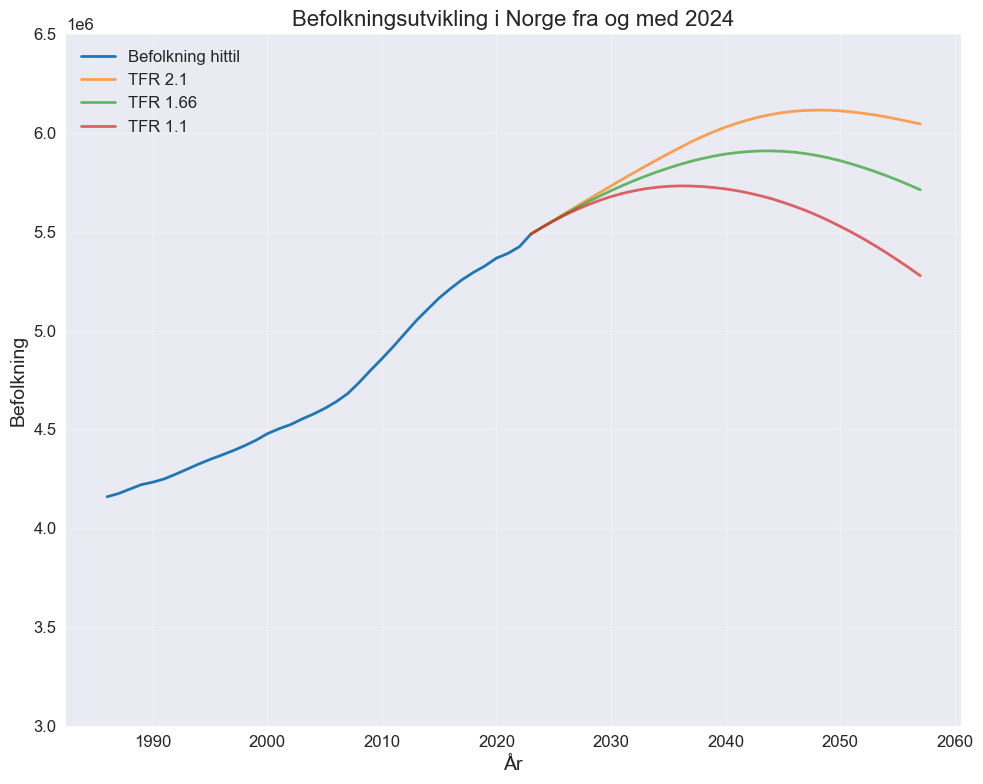

In [115]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(befolkning_til_nå.år, befolkning_til_nå["pop"], label='Befolkning hittil', color=colors_tfr[0], linewidth=2)
ax.plot(befolkning.år, befolkning["pop_2.1"], color=colors_tfr[1], alpha=0.7, linewidth=2, label='TFR 2.1')
ax.plot(befolkning.år, befolkning["pop_1.66"], color=colors_tfr[2], alpha=0.7, linewidth=2, label='TFR 1.66')
ax.plot(befolkning.år, befolkning["pop_1.1"], color=colors_tfr[3], alpha=0.7, linewidth=2, label='TFR 1.1')

ax.set_ylim(3e6, 65e5)
ax.set_ylabel('Befolkning')
ax.set_xlabel('År')
ax.set_title('Befolkningsutvikling i Norge fra og med 2024')
ax.legend()

plt.tight_layout()


In [116]:
befolkning["pop_2023"] = befolkning_til_nå.loc[lambda x: x.år == 2023]["pop"].values[0]

In [117]:
befolkning = befolkning.assign(
    pop_1_66_endring = lambda x: x["pop_1.66"] - x["pop_2023"],
    pop_2_endring = lambda x: x["pop_2.1"] - x["pop_2023"],
    pop_1_1_endring = lambda x: x["pop_1.1"] - x["pop_2023"],
)
befolkning

,år,pop_1.66,pop_2.1,pop_1.1,pop_2023,pop_1_66_endring,pop_2_endring,pop_1_1_endring
0,2023,5488984,5488984,5488984,5488984,0,0,0
1,2024,5523870,5524064,5523932,5488984,34886,35080,34948
2,2025,5557740,5558835,5556343,5488984,68756,69851,67359
3,2026,5590626,5594099,5586193,5488984,101642,105115,97209
4,2027,5622155,5629238,5613244,5488984,133171,140254,124260
5,2028,5652548,5664147,5637708,5488984,163564,175163,148724
6,2029,5681471,5698684,5659848,5488984,192487,209700,170864
7,2030,5708867,5732939,5678906,5488984,219883,243955,189922
8,2031,5734865,5767004,5695147,5488984,245881,278020,206163
9,2032,5759520,5800010,5708134,5488984,270536,311026,219150


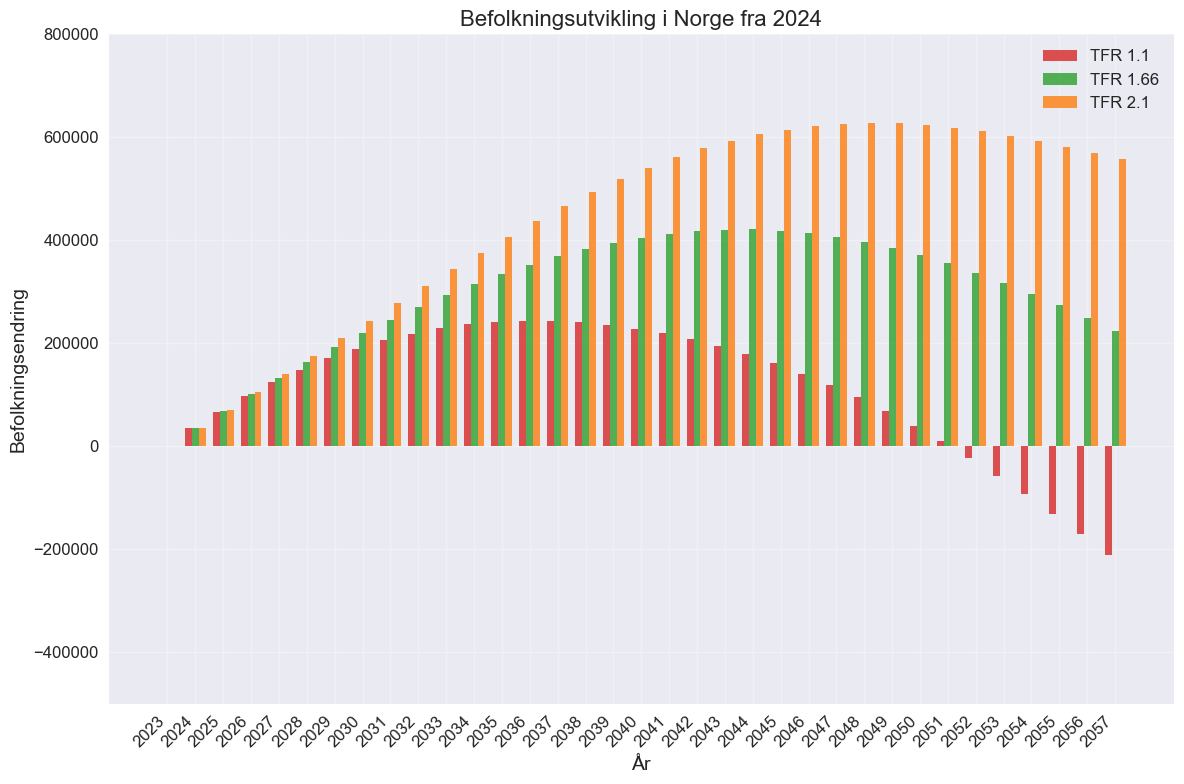

In [118]:
width = 0.25  # Width of the bars

x = np.arange(len(befolkning.år))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(x - width, befolkning["pop_1_1_endring"], width, color=colors_tfr[3], alpha=0.8, label='TFR 1.1')
ax.bar(x, befolkning["pop_1_66_endring"], width, color=colors_tfr[2], alpha=0.8, label='TFR 1.66')
ax.bar(x +  width, befolkning["pop_2_endring"], width, color=colors_tfr[1], alpha=0.8, label='TFR 2.1')

ax.set_ylim(-0.5e6, 8e5)
ax.set_ylabel('Befolkningsendring')
ax.set_xlabel('År')
ax.set_xticks(x)
ax.set_xticklabels(befolkning.år, rotation=45, ha='right')
ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()

plt.tight_layout()


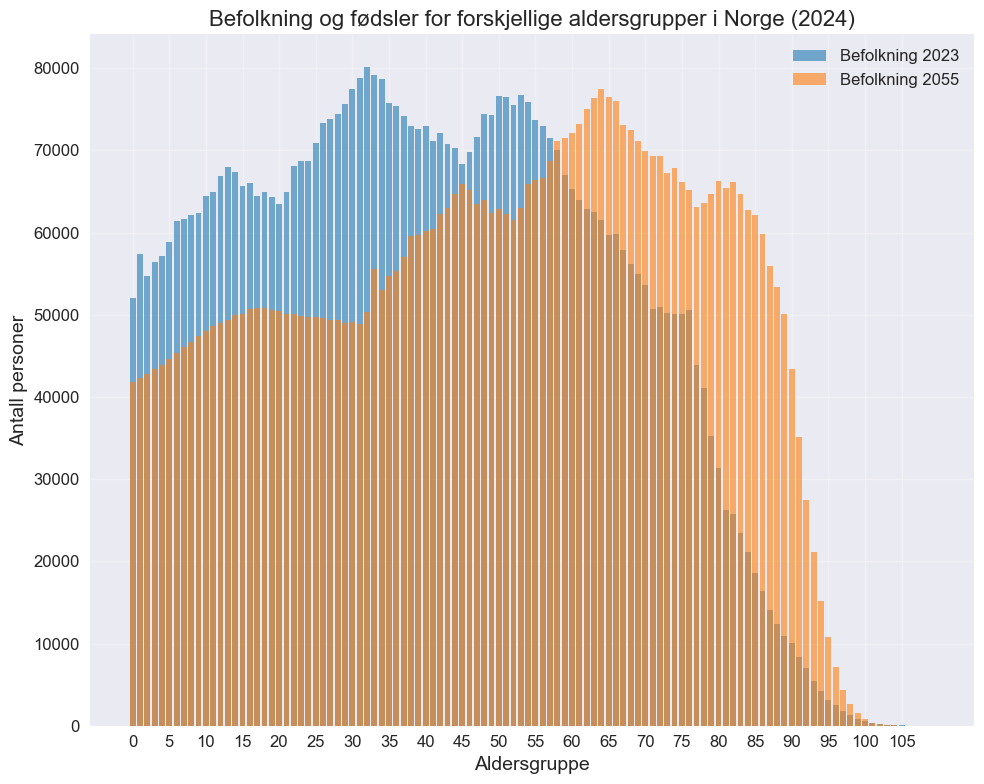

In [119]:
pop = pd.read_csv(data / 'popfordeling_2023-2073_tfr1_66.csv').iloc[:,:93]

year_from = 2023
year_to =  2023 + 32

pop = pop[["sex","alder", f"pop_{year_from}", f"pop_{year_to}"]]

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
pop_total = pop.groupby("alder")[["pop_2023", "pop_2055"]].sum().reset_index()

ax.bar(pop_total.index, pop_total[f"pop_{year_from}"], color=colors_tfr[0], alpha=0.6, label='Befolkning 2023')
ax.bar(pop_total.index, pop_total[f"pop_{year_to}"], color=colors_tfr[1], alpha=0.6, label='Befolkning 2055')



ax.set_ylabel('Antall personer')
ax.set_xlabel('Aldersgruppe')
ax.set_title('Befolkning og fødsler for forskjellige aldersgrupper i Norge (2024)')
ax.legend()

# Customizing the x-axis
ax.set_xticks(range(0, len(pop_total.index), 5))
ax.set_xticklabels(range(0, len(pop_total.index), 5))

plt.tight_layout()


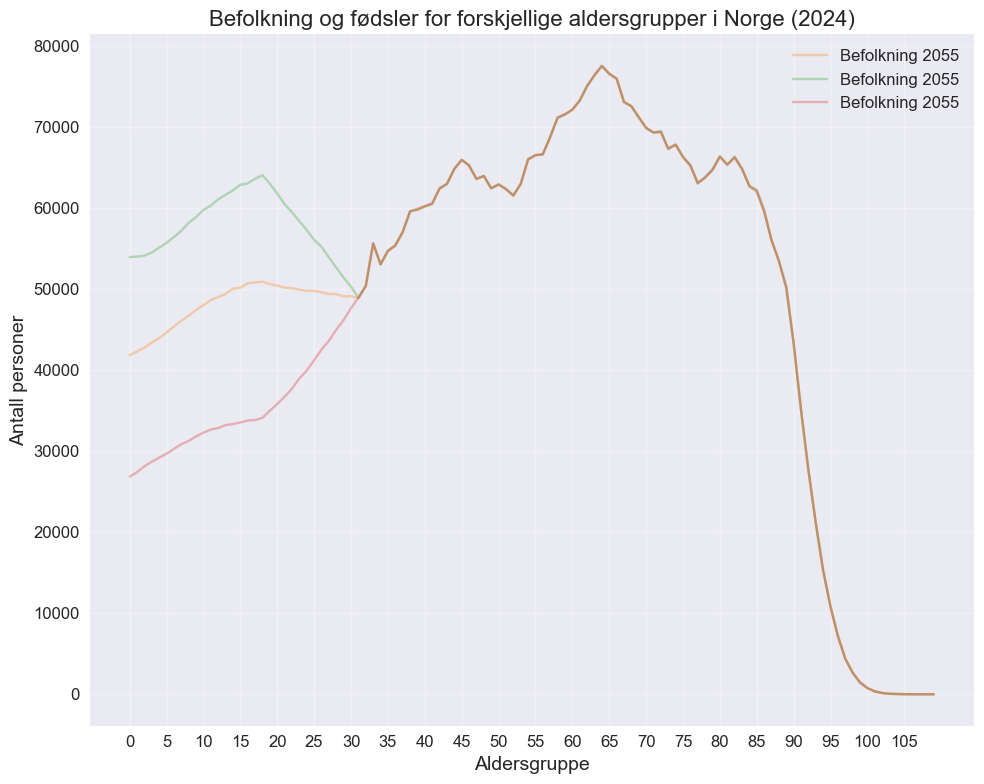

In [120]:
pop_1 = pd.read_csv(data / 'popfordeling_2023-2073_tfr1_66.csv').iloc[:,:93]
pop_2 = pd.read_csv(data / 'popfordeling_2023-2073_tfr2_1.csv').iloc[:,:93]
pop_3 = pd.read_csv(data / 'popfordeling_2023-2073_tfr1_1.csv').iloc[:,:93]

year_from = 2023
year_to =  2023 + 32

pop = pop[["sex","alder", f"pop_{year_from}", f"pop_{year_to}"]]

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
pop_total_1 = pop_1.groupby("alder")[["pop_2023", "pop_2055"]].sum().reset_index()
pop_total_2 = pop_2.groupby("alder")[["pop_2023", "pop_2055"]].sum().reset_index()
pop_total_3 = pop_3.groupby("alder")[["pop_2023", "pop_2055"]].sum().reset_index()


ax.plot(pop_total_1.index, pop_total_1[f"pop_{year_to}"], color=colors_tfr[1], alpha=0.3, label='Befolkning 2055')
ax.plot(pop_total_2.index, pop_total_2[f"pop_{year_to}"], color=colors_tfr[2], alpha=0.3, label='Befolkning 2055')
ax.plot(pop_total_3.index, pop_total_3[f"pop_{year_to}"], color=colors_tfr[3], alpha=0.3, label='Befolkning 2055')

ax.set_ylabel('Antall personer')
ax.set_xlabel('Aldersgruppe')
ax.set_title('Befolkning og fødsler for forskjellige aldersgrupper i Norge (2024)')
ax.legend()

# Customizing the x-axis
ax.set_xticks(range(0, len(pop_total_1.index), 5))
ax.set_xticklabels(range(0, len(pop_total_1.index), 5))

plt.tight_layout()


In [121]:
pop_total.to_clipboard()

In [122]:
import altair as alt
import pandas as pd
from pathlib import Path

# Load data
pop = pd.read_csv('data/popfordeling_2023-2073_tfr1_66.csv').iloc[:,:93]

# Create age bins (10-year intervals)
bins = list(range(0, 110, 10))
labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] 
pop['alder_bins'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
grouped_data = pop.groupby("alder_bins", observed=False)[["pop_2023", "pop_2058"]].sum().reset_index()

# 1. Dumbbell Plot
melted_data = grouped_data.melt(id_vars=['alder_bins'], var_name='year', value_name='population')
melted_data = melted_data.loc[lambda x: x['alder_bins'] != '100+']
age_order = labels 

In [123]:
melted_data["year"] = melted_data["year"].str.replace("pop_", "")

In [124]:
# 3. Difference Chart
grouped_data['diff'] = grouped_data['pop_2058'] - grouped_data['pop_2023']
grouped_data['change_type'] = grouped_data['diff'].apply(lambda x: 'Økning' if x > 0 else 'Reduksjon')

diff_chart = alt.Chart(grouped_data).mark_bar().encode(
    x=alt.X('diff:Q', title='Endring i befolkning (2023 - 2058)'),
    y=alt.Y('alder_bins:N', sort=age_order, title='Aldersgrupper'),
    color=alt.Color('change_type:N', scale=alt.Scale(domain=['Økning', 'Reduksjon'], range=[colors_tfr[1], colors_tfr[0]]), title='Endringstype'),
    tooltip=['alder_bins', 'diff']
).properties(
    title='Netto befolkningsendring per aldersgruppe',
    width=400
).interactive()

# Display both
(diff_chart)

alt.Chart(...)

In [125]:
labels

['0-9',
 '10-19',
 '20-29',
 '30-39',
 '40-49',
 '50-59',
 '60-69',
 '70-79',
 '80-89',
 '90-99']

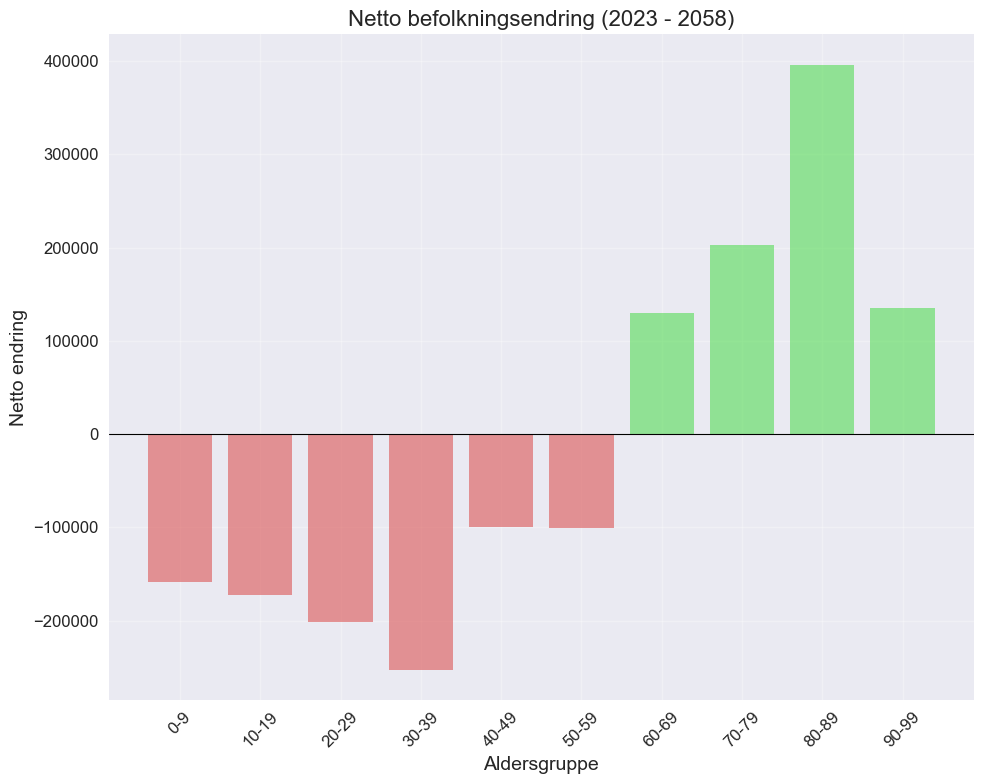

In [128]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#55dc55" if x > 0 else "#db5454" for x in grouped_data['diff']]

ax.bar(labels, grouped_data['diff'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_ylabel('Netto endring')
ax.set_xlabel('Aldersgruppe')
ax.set_title('Netto befolkningsendring (2023 - 2058)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

In [19]:
import altair as alt
import pandas as pd
from pathlib import Path

# Load data
data_path = Path("data") / "popfordeling_2023-2073_tfr1_66.csv"
pop = pd.read_csv(data_path)

# Create age groups
bins = [0, 20, 65, np.inf]
labels = ['0-19', '20-64', '65+']
pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
cols = [f"pop_{year}" for year in range(2023, 2059)]
grouped_data = pop.groupby("age_group", observed=False)[cols].sum().reset_index()

# Calculate difference from 2023 for each year
for year in range(2024, 2059):
    grouped_data[f"diff_{year}"] = grouped_data[f"pop_{year}"] - grouped_data["pop_2023"]

# Melt for plotting
diff_cols = [f"diff_{year}" for year in range(2024, 2059)]
melted_data = grouped_data.melt(id_vars=['age_group'], value_vars=diff_cols, var_name='year', value_name='diff')
melted_data['year'] = melted_data['year'].str.replace("diff_", "").astype(int)

# Calculate support ratio (working-age / dependents)
support_ratios = []
for year in range(2024, 2059):
    working = grouped_data.loc[grouped_data['age_group'] == '20-64', f'pop_{year}'].values[0]
    young = grouped_data.loc[grouped_data['age_group'] == '0-19', f'pop_{year}'].values[0]
    old = grouped_data.loc[grouped_data['age_group'] == '65+', f'pop_{year}'].values[0]
    # ratio = working / (young + old) if (young + old) > 0 else 0
    ratio = working / old if old > 0 else 0
    support_ratios.append({'year': year, 'support_ratio': ratio})

support_df = pd.DataFrame(support_ratios)

In [30]:
# Load data
data_path = Path("data") / "popfordeling_2023-2073_tfr1_66.csv"
pop = pd.read_csv(data_path)

# Create age groups
bins = [0, 20, 65, np.inf]
labels = ['0-19', '20-64', '65+']
pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
cols = [f"pop_{year}" for year in range(2023, 2059)]
grouped_data = pop.groupby("age_group", observed=False)[cols].sum().reset_index()

# Calculate ratios
ratio_full_values = grouped_data.iloc[1, 1:] / (grouped_data.iloc[0, 1:] + grouped_data.iloc[2, 1:])
ratio_old_values = grouped_data.iloc[1, 1:] / grouped_data.iloc[2, 1:]

# Create DataFrame rows for ratios
ratio_full_row = pd.DataFrame([{'age_group': 'ratio_full', **ratio_full_values.to_dict()}])
ratio_old_row = pd.DataFrame([{'age_group': 'ratio_old', **ratio_old_values.to_dict()}])

# Concatenate the rows to grouped_data
grouped_data = pd.concat([grouped_data, ratio_full_row, ratio_old_row], ignore_index=True)
grouped_data

,age_group,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,pop_2031,...,pop_2049,pop_2050,pop_2051,pop_2052,pop_2053,pop_2054,pop_2055,pop_2056,pop_2057,pop_2058
0,0-19,1.241427e+06,1.226337e+06,1.211911e+06,1.199446e+06,1.186801e+06,1.175604e+06,1.163916e+06,1.152910e+06,1.144229e+06,...,1.213404e+06,1.211545e+06,1.207862e+06,1.202860e+06,1.196251e+06,1.188525e+06,1.179395e+06,1.169524e+06,1.158893e+06,1.149120e+06
1,20-64,3.236096e+06,3.235527e+06,3.234625e+06,3.232914e+06,3.231696e+06,3.228900e+06,3.226104e+06,3.220737e+06,3.212962e+06,...,2.882069e+06,2.864494e+06,2.847145e+06,2.829577e+06,2.813002e+06,2.794567e+06,2.776947e+06,2.759438e+06,2.744330e+06,2.730211e+06
2,65+,1.011461e+06,1.062200e+06,1.112299e+06,1.161739e+06,1.210741e+06,1.259643e+06,1.308664e+06,1.359292e+06,1.409813e+06,...,2.020866e+06,2.037093e+06,2.052724e+06,2.068389e+06,2.083202e+06,2.099418e+06,2.114730e+06,2.129963e+06,2.143510e+06,2.154437e+06
3,ratio_full,1.436421e+00,1.413797e+00,1.391709e+00,1.369191e+00,1.347920e+00,1.325902e+00,1.304752e+00,1.282037e+00,1.257991e+00,...,8.911034e-01,8.817523e-01,8.732004e-01,8.649837e-01,8.577656e-01,8.499439e-01,8.429999e-01,8.363233e-01,8.310100e-01,8.264459e-01
4,ratio_old,3.199427e+00,3.046062e+00,2.908054e+00,2.782823e+00,2.669189e+00,2.563345e+00,2.465189e+00,2.369422e+00,2.278999e+00,...,1.426155e+00,1.406168e+00,1.387008e+00,1.368010e+00,1.350326e+00,1.331115e+00,1.313145e+00,1.295533e+00,1.280297e+00,1.267250e+00


In [31]:
pop_cols = [f"pop_{year}" for year in range(2023, 2059)]

# stack_data: transpose age group rows so years become the index
stack_data = (
    grouped_data[grouped_data['age_group'].isin(['0-19', '20-64', '65+'])]
    .set_index('age_group')[pop_cols]
    .T
)
stack_data.index = stack_data.index.str.replace('pop_', '').astype(int)
stack_data.index.name = 'year'

# ratio_full and ratio_old: transpose the ratio rows into long-form DataFrames
def extract_ratio(name):
    row = (
        grouped_data.loc[grouped_data['age_group'] == name, pop_cols]
        .T
        .reset_index()
    )
    row.columns = ['year', name]
    row['year'] = row['year'].str.replace('pop_', '').astype(int)
    return row

ratio_full = extract_ratio('ratio_full')
ratio_old = extract_ratio('ratio_old')


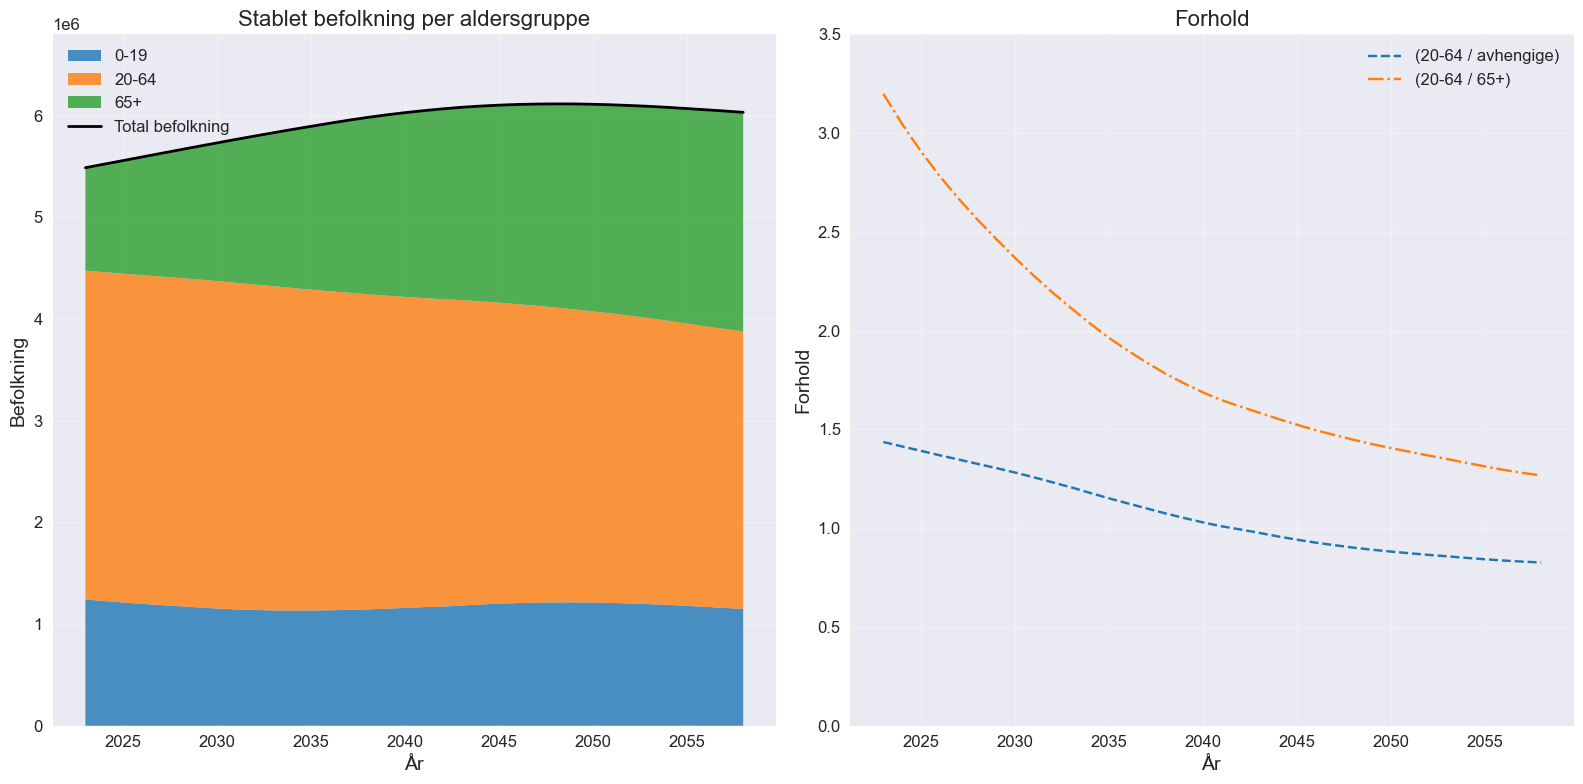

In [130]:
# Plot with subplots: stacked populations on left, ratios on right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Stacked area plot for populations with improved styling
ax1.stackplot(stack_data.index, stack_data['0-19'], stack_data['20-64'], stack_data['65+'], labels=['0-19', '20-64', '65+'], colors=colors_age, alpha=0.8)

# Add prominent line for total population
total_pop = stack_data.sum(axis=1)
ax1.plot(stack_data.index, total_pop, color='black', linewidth=2, label='Total befolkning')

ax1.set_ylabel('Befolkning')
ax1.set_xlabel('År')
ax1.set_title('Stablet befolkning per aldersgruppe')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 6.8e6)

# Ratios plot
ax2.plot(ratio_full['year'], ratio_full['ratio_full'], label='(20-64 / avhengige)', color=colors_tfr[0], linestyle='--')
ax2.plot(ratio_old['year'], ratio_old['ratio_old'], label='(20-64 / 65+)', color=colors_tfr[1], linestyle='-.')
ax2.set_ylabel('Forhold')
ax2.set_xlabel('År')
ax2.set_title('Forhold')
ax2.legend(loc='upper right')
ax2.set_ylim(0,3.5)

plt.tight_layout()
plt.show()

In [ ]:
data_path_1 = Path("data") / "popfordeling_2023-2073_tfr1_66.csv"
data_path_2 = Path("data") / "popfordeling_2023-2073_tfr2_1.csv"
data_path_3 = Path("data") / "popfordeling_2023-2073_tfr1_1.csv"

# Helper to load a popfordeling file and extract ratio_old (20-64 / 65+)
def load_ratio_old(path, year_to=2073):
    pop = pd.read_csv(path)
    bins = [0, 20, 65, np.inf]
    labels = ['0-19', '20-64', '65+']
    pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

    cols = [f"pop_{year}" for year in range(2023, year_to + 1)]
    grouped = pop.groupby("age_group", observed=False)[cols].sum()

    ratio_old = grouped.loc['20-64'] / grouped.loc['65+']
    return pd.DataFrame({
        'year': range(2023, year_to + 1),
        'ratio_old': ratio_old.values
    })

# Load all three
ratio_old_166 = load_ratio_old(Path("data") / "popfordeling_2023-2073_tfr1_66.csv")
ratio_old_21  = load_ratio_old(Path("data") / "popfordeling_2023-2073_tfr2_1.csv")
ratio_old_11  = load_ratio_old(Path("data") / "popfordeling_2023-2073_tfr1_1.csv")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ratio_old_21['year'],  ratio_old_21['ratio_old'],  label='TFR 2.1',  color=colors_tfr[1], linewidth=2)
ax.plot(ratio_old_166['year'], ratio_old_166['ratio_old'], label='TFR 1.66', color=colors_tfr[2], linewidth=2)
ax.plot(ratio_old_11['year'],  ratio_old_11['ratio_old'],  label='TFR 1.1',  color=colors_tfr[3], linewidth=2)

ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')  # parity reference
ax.set_ylabel('Forsørgerandel (20-64 / 65+)')
ax.set_xlabel('År')
ax.set_title('Forsørgerandel per fertilitetsrate (2023–2073)')
ax.legend()
ax.set_ylim(0, 3.5)

plt.tight_layout()
plt.show()


/var/folders/0k/kjly72p17y1gxqhyj4zvz9yh0000gn/T/ipykernel_82230/1542290902.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)


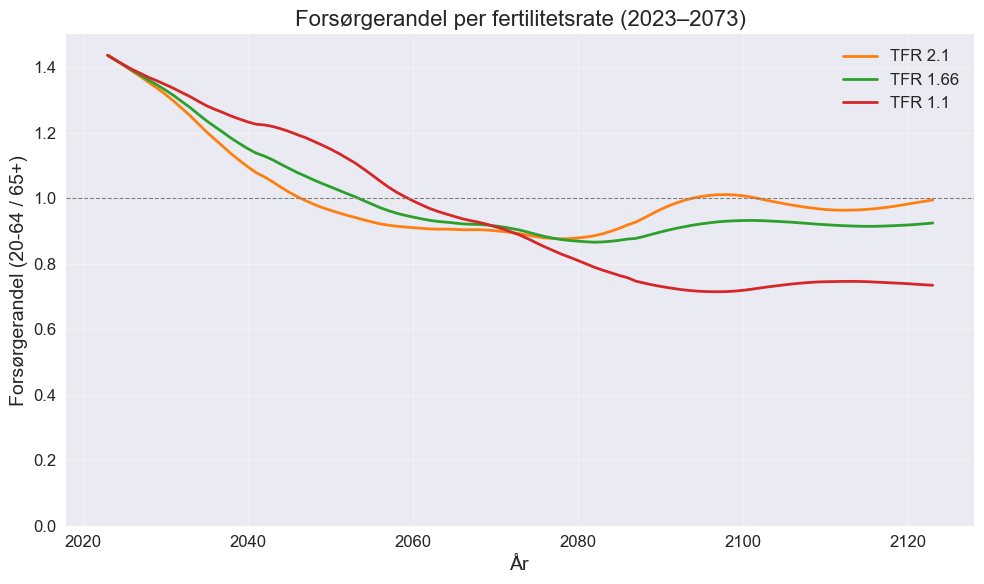

In [134]:
# Helper to load a popfordeling file and extract ratio_old (20-64 / 65+)
def load_ratio_old(path, year_to=2123):
    pop = pd.read_csv(path)
    bins = [0, 20, 65, np.inf]
    labels = ['0-19', '20-64', '65+']
    pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

    cols = [f"pop_{year}" for year in range(2023, year_to + 1)]
    grouped = pop.groupby("age_group", observed=False)[cols].sum()

    ratio_old = grouped.loc['20-64'] / (grouped.loc['65+'] + grouped.loc['0-19'])
    return pd.DataFrame({
        'year': range(2023, year_to + 1),
        'ratio_old': ratio_old.values
    })

# Load all three
ratio_old_166 = load_ratio_old(Path("data") / "popfordeling_2023-2123_tfr1_66.csv")
ratio_old_21  = load_ratio_old(Path("data") / "popfordeling_2023-2123_tfr2_1.csv")
ratio_old_11  = load_ratio_old(Path("data") / "popfordeling_2023-2123_tfr1_1.csv")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ratio_old_21['year'],  ratio_old_21['ratio_old'],  label='TFR 2.1',  color=colors_tfr[1], linewidth=2)
ax.plot(ratio_old_166['year'], ratio_old_166['ratio_old'], label='TFR 1.66', color=colors_tfr[2], linewidth=2)
ax.plot(ratio_old_11['year'],  ratio_old_11['ratio_old'],  label='TFR 1.1',  color=colors_tfr[3], linewidth=2)

ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')  # parity reference
ax.set_ylabel('Forsørgerandel (20-64 / 65+)')
ax.set_xlabel('År')
ax.set_title('Forsørgerandel per fertilitetsrate (2023–2073)')
ax.legend()
ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()


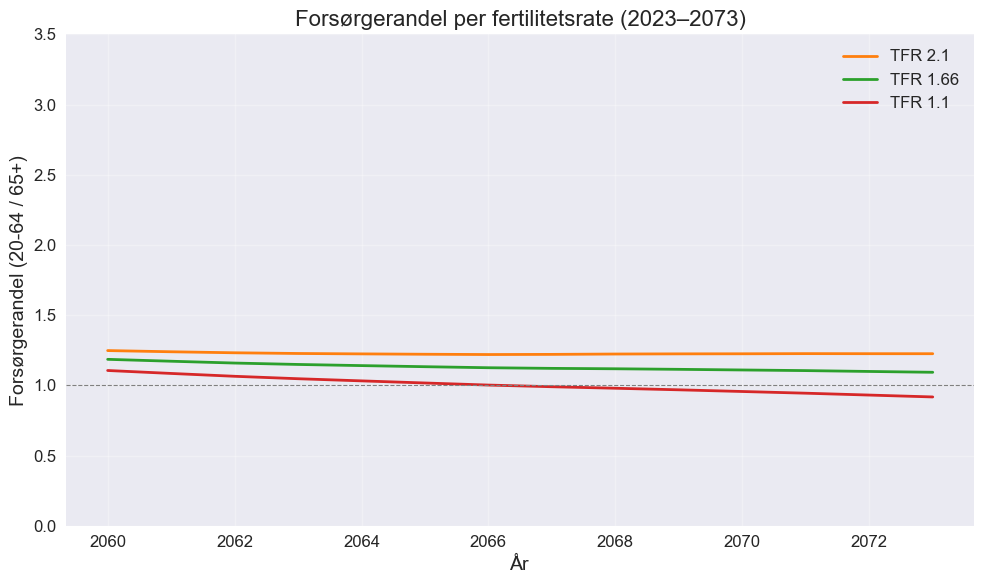

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

year = 2060

# starting at tear 2040 isntead
ratio_old_21 = ratio_old_21.loc[lambda x: x.year >= year]
ratio_old_166 = ratio_old_166.loc[lambda x: x.year >= year]
ratio_old_11 = ratio_old_11.loc[lambda x: x.year >= year]

ax.plot(ratio_old_21['year'],  ratio_old_21['ratio_old'],  label='TFR 2.1',  color=colors_tfr[1], linewidth=2)
ax.plot(ratio_old_166['year'], ratio_old_166['ratio_old'], label='TFR 1.66', color=colors_tfr[2], linewidth=2)
ax.plot(ratio_old_11['year'],  ratio_old_11['ratio_old'],  label='TFR 1.1',  color=colors_tfr[3], linewidth=2)

ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')  # parity reference
ax.set_ylabel('Forsørgerandel (20-64 / 65+)')
ax.set_xlabel('År')
ax.set_title('Forsørgerandel per fertilitetsrate (2023–2073)')
ax.legend()
ax.set_ylim(0, 3.5)

plt.tight_layout()
plt.show()


In [70]:
populasjon = pd.read_csv(data / "populasjon_2073_tfr1_66.csv").iloc[:,:93]

In [75]:
populasjon

,sex,alder,barn
0,M,50.0,0.0
1,M,50.0,0.0
2,M,50.0,0.0
3,M,50.0,0.0
4,M,50.0,0.0
...,...,...,...
4844770,K,0.0,0.0
4844771,K,0.0,0.0
4844772,M,0.0,0.0
4844773,K,0.0,0.0


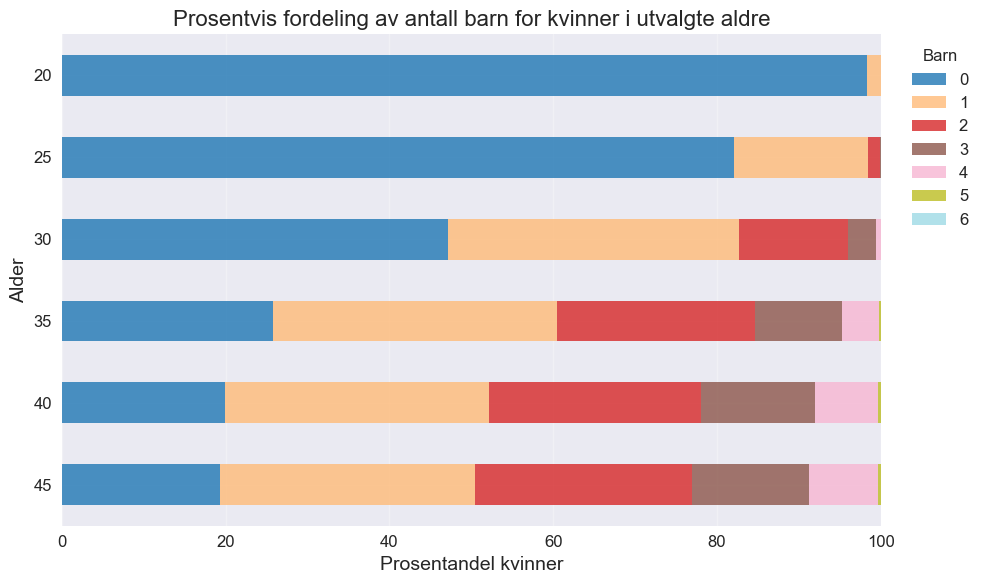

In [97]:
ages = [45, 40, 35, 30 , 25, 20]

subset = (
    populasjon.loc[
        lambda x: (x.sex == "K") & x.alder.astype(int).isin(ages),
        ["alder", "barn"]
    ]
    .dropna(subset=["barn"])
)

barn_counts = pd.crosstab(
    subset.alder.astype(int),
    subset.barn.astype(int)
).reindex(ages).fillna(0)

barn_percent = barn_counts.div(barn_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
barn_percent.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    colormap="tab20",
    alpha=0.8
)

ax.set_xlabel("Prosentandel kvinner")
ax.set_ylabel("Alder")
ax.set_title("Prosentvis fordeling av antall barn for kvinner i utvalgte aldre")
ax.set_xlim(0, 100)
ax.legend(title="Barn", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()